# Hashline hypothesis report — visualizations

Full narrative, hypotheses, and methodology: [hashline_hypothesis_report.md](hashline_hypothesis_report.md).

Data: `reports/2026-05-23T13-22-35.666225+00-00_local-r_matrix.json` (50 runs).

Wrote figures to /Users/leshchenko/coding_projects/harness_test/docs/figures


,pass_rate,turns,tokens
variant,,,
baseline,0.9,4.9,8412.2
opencrabs_h1_docs,0.9,5.9,27383.8
opencrabs_h2_fuzzy,1.0,5.3,20115.1
opencrabs_h3_collision,0.7,9.0,46785.4
opencrabs_original,0.9,5.3,30696.5


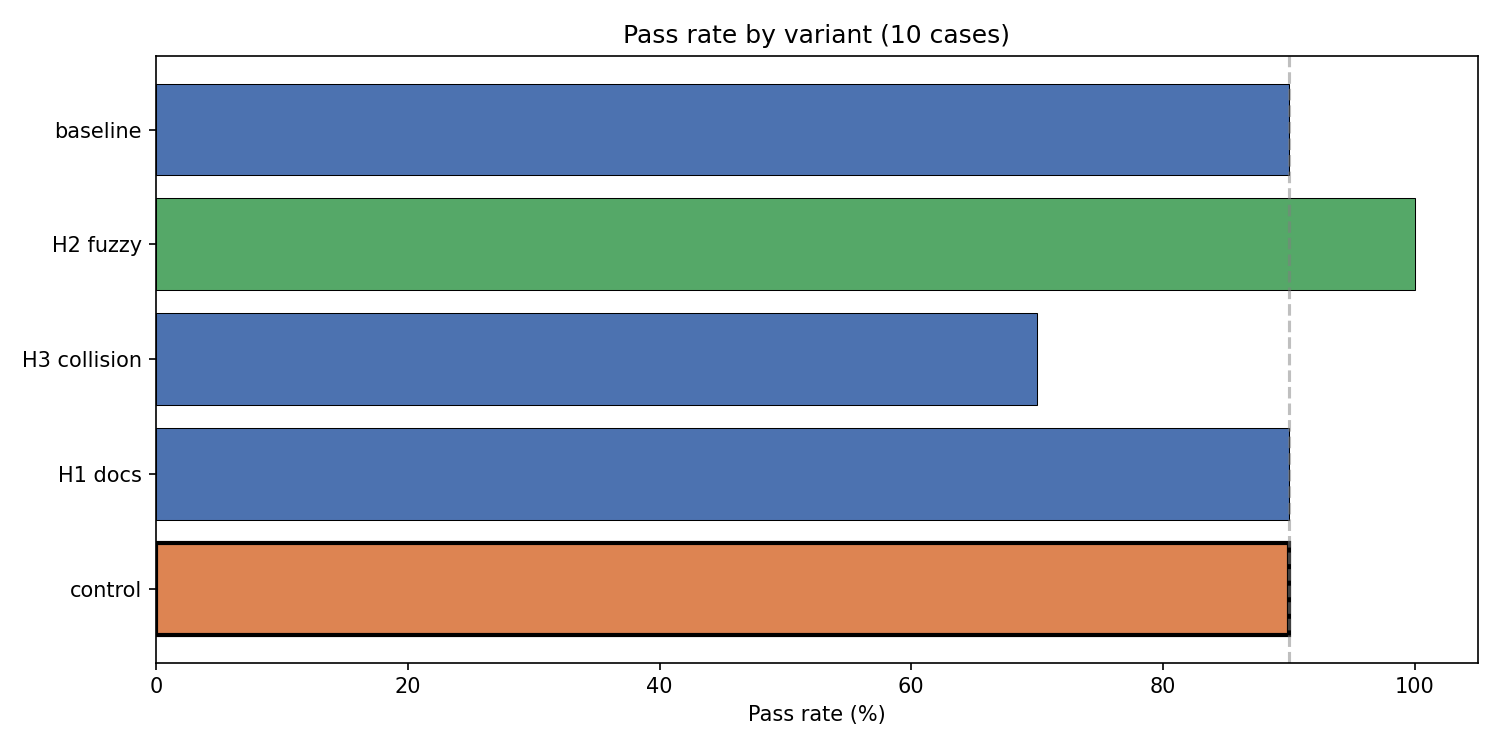

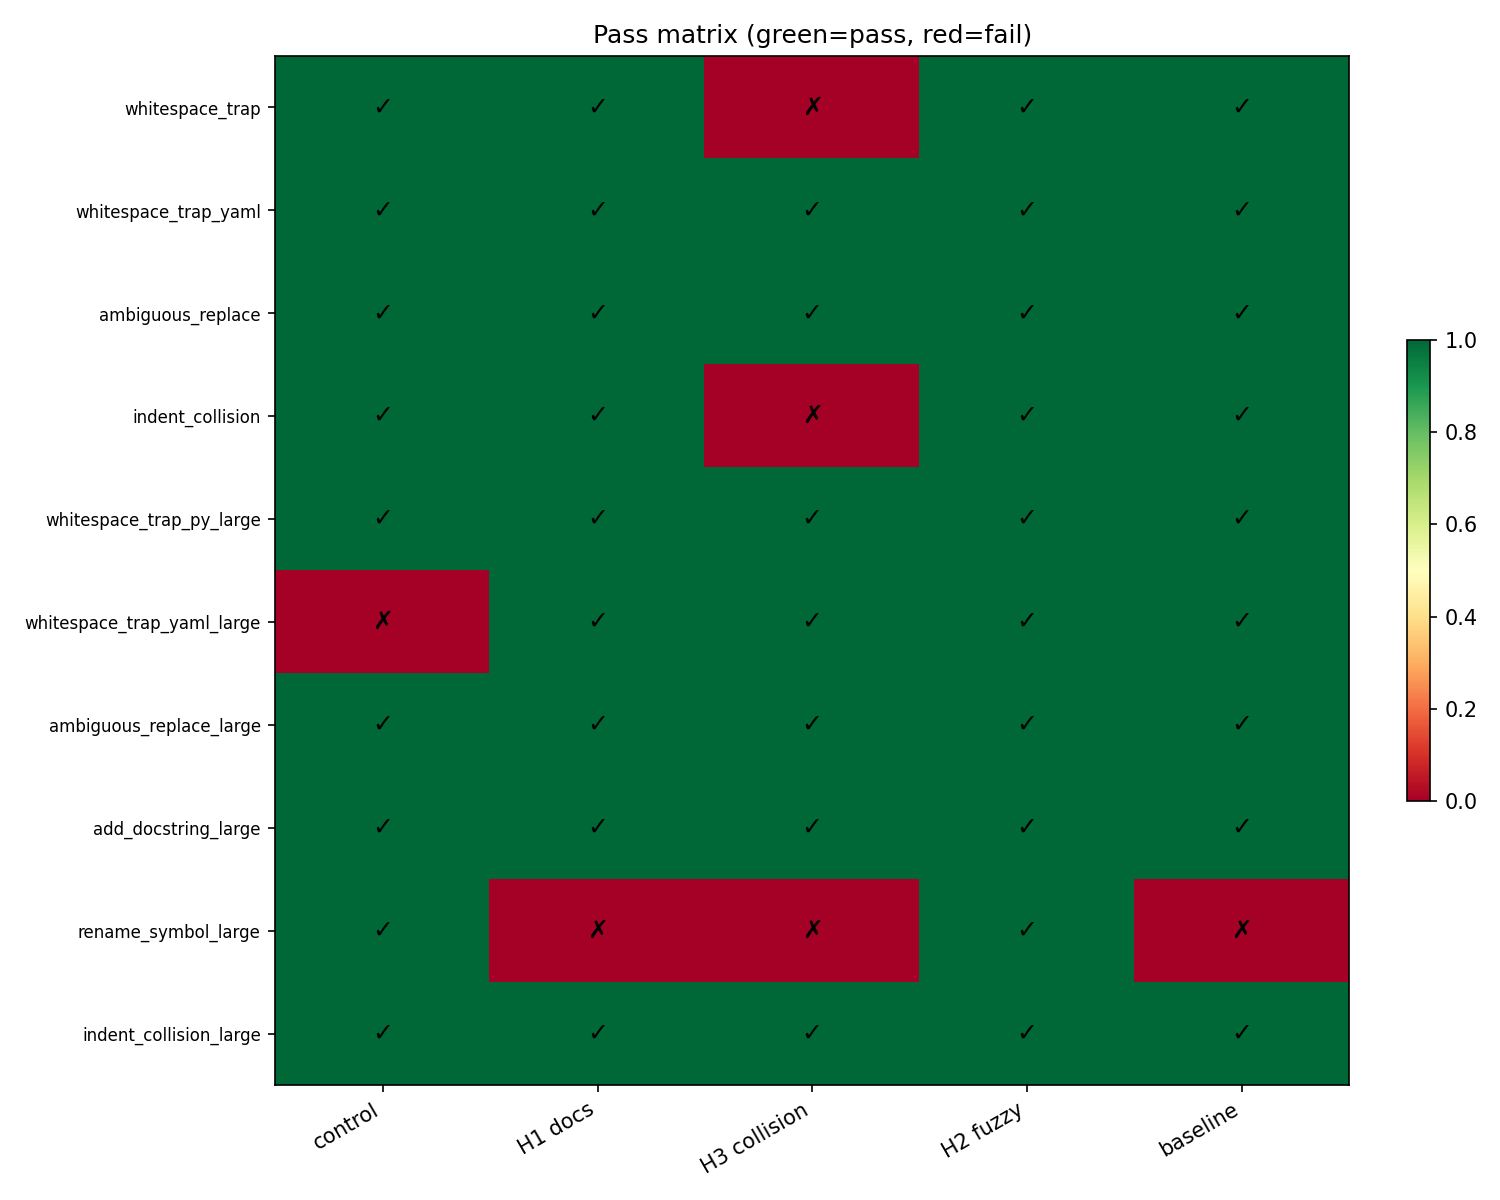

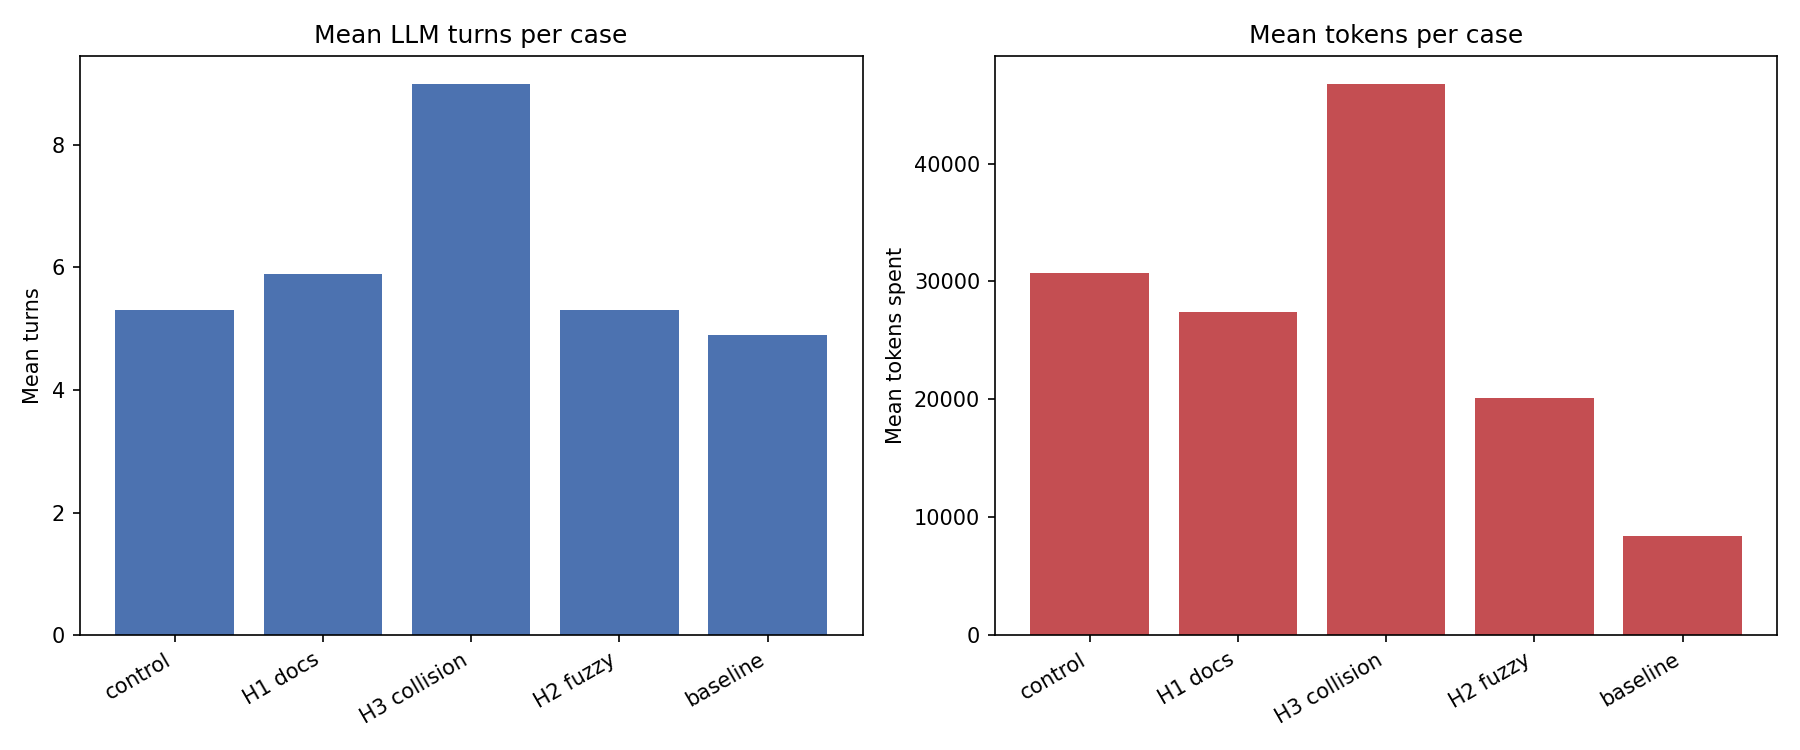

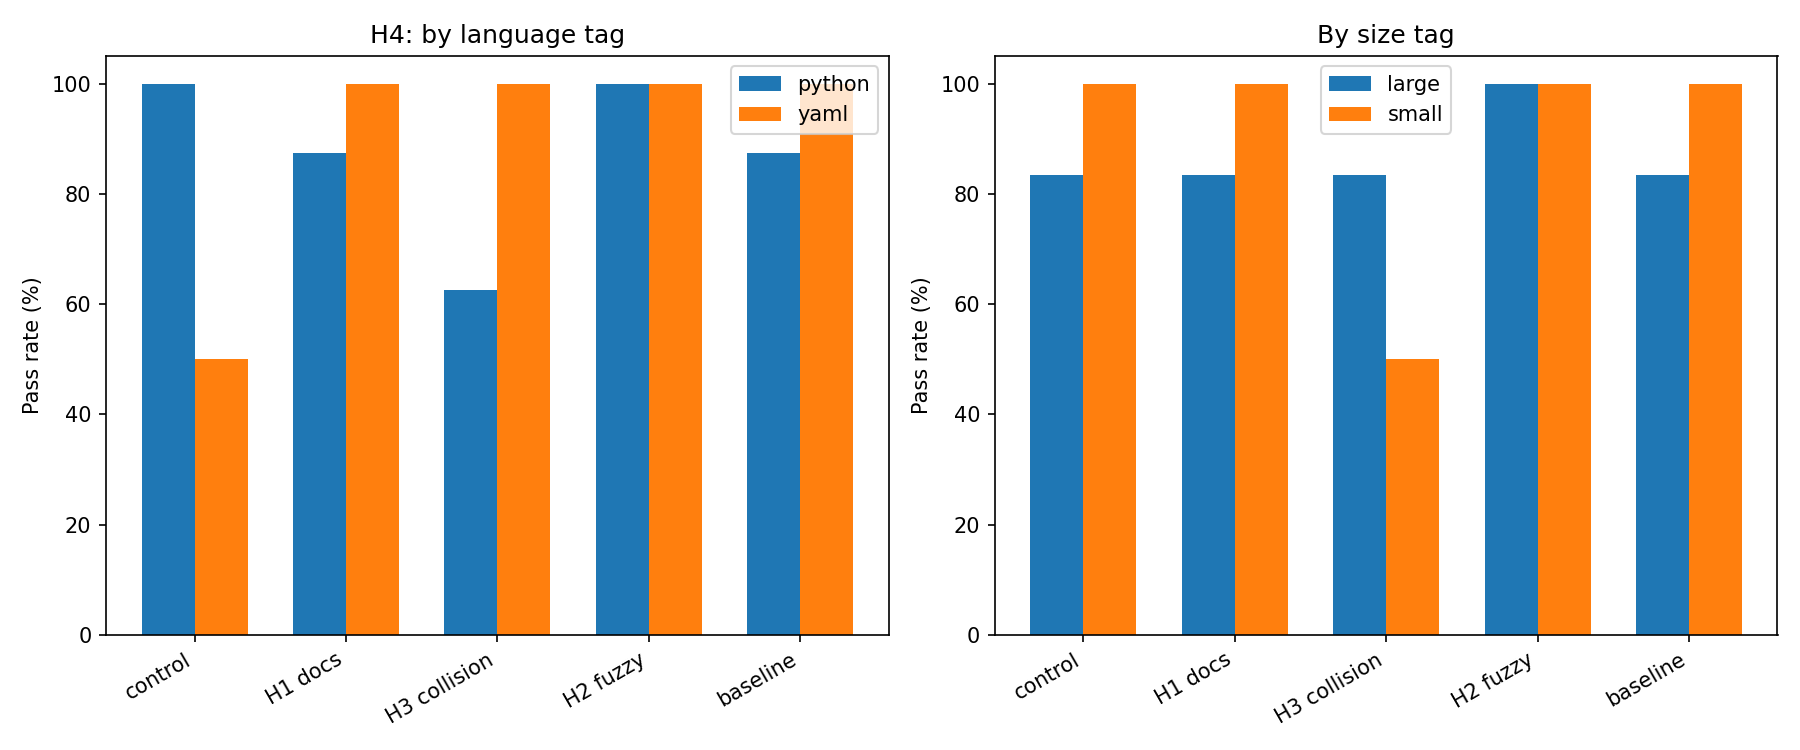

In [1]:

from pathlib import Path
import json
import subprocess
import sys

# Regenerate figures (same logic as committed PNGs)
subprocess.check_call([sys.executable, str(Path("docs/_build_report_viz.py"))], cwd=Path(".").resolve())

import pandas as pd
from IPython.display import Image, display

REPORT = Path("reports/2026-05-23T13-22-35.666225+00-00_local-r_matrix.json")
data = json.loads(REPORT.read_text())
rows = [{
    "variant": r["variant_id"].rsplit("/", 1)[0],
    "case_name": r["case_name"],
    "passed": r["passed"],
    "turns": r.get("turns", 0),
    "tokens_spent": r.get("tokens_spent", 0),
} for r in data["results"]]
df = pd.DataFrame(rows)
summary = df.groupby("variant").agg(
    pass_rate=("passed", "mean"),
    turns=("turns", "mean"),
    tokens=("tokens_spent", "mean"),
).round(2)
display(summary)

figs = [
    "pass_rate_by_variant.png",
    "pass_matrix_heatmap.png",
    "efficiency_tokens_turns.png",
    "h4_and_size_buckets.png",
]
for f in figs:
    display(Image(filename=f"docs/figures/{f}"))
